# This jupyter notebook is prepared by “Sejal Mogalgiddi”

##Load Data and perform basic EDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from wordcloud import WordCloud
import seaborn as sns
from sklearn.model_selection import train_test_split

#nltk operations
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
news = [line.rstrip() for line in open('news.csv')]
#print first 10 lines
for new in news[:10]:
    print(new)
    print('\n')
#document is seperated with tab chars : \t
df=  pd.read_csv('news.csv', sep = '\t')

print("First 5 rows:\n")
print(df.head())

print("\nLast 5 rows:\n")
print(df.tail())


title	text	subject	date	target


As U.S. budget fight looms, Republicans flip their fiscal script	WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also wan

In [ ]:
print("Null before cleaning\n")
print(df.isnull().sum())
print(df.shape)

df = df.dropna()
print(df.shape)

print(df.isnull().sum())


Null before cleaning

title      0
text       0
subject    0
date       0
target     0
dtype: int64
(44898, 5)
(44898, 5)
title      0
text       0
subject    0
date       0
target     0
dtype: int64


There are no null values in our dataset, as proven when we used df.isnull().sum() to check if there are any. We got 0's for all of the variables. We also checked the shape and came to the same conclusion then too.

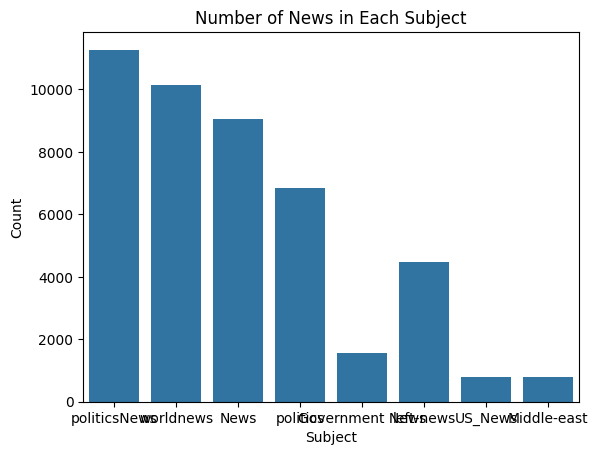

In [ ]:
sns.countplot(x='subject', data=df)
plt.title("Number of News in Each Subject")
plt.xlabel("Subject")
plt.ylabel("Count")

plt.show()

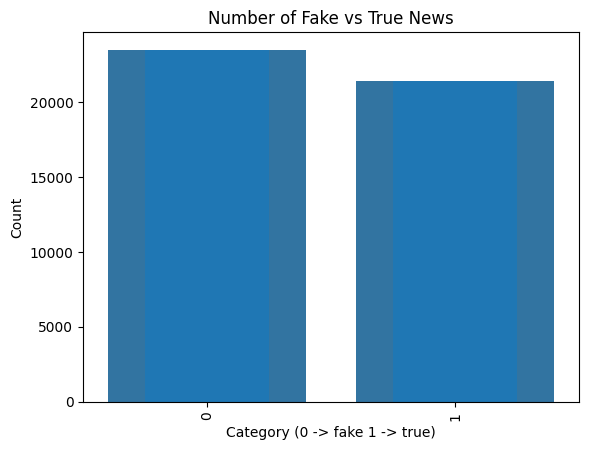

In [ ]:
#counter plots for fake vs true news
sns.countplot(x='target', data=df)

df['target'].value_counts().plot(kind='bar')

plt.title("Number of Fake vs True News")
plt.xlabel("Category (0 -> fake 1 -> true)")
plt.ylabel("Count")

plt.show()

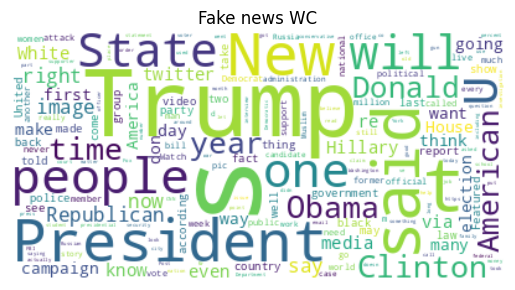

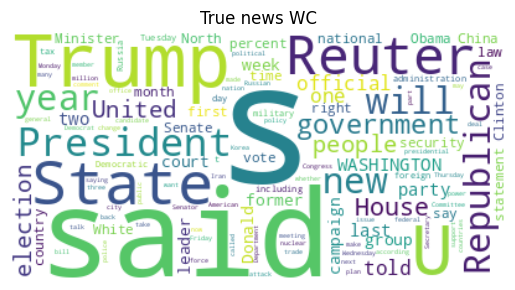

In [ ]:
#wordcloud for fake vs tru news

fake_news = df[df['target'] == 0]
true_news = df[df['target'] == 1]
fake_text = " ".join(text for text in fake_news['text'])
true_text = " ".join(text for text in true_news['text'])

fake_wc = WordCloud(collocations=False, background_color='white').generate(fake_text)
true_wc = WordCloud(collocations=False, background_color='white').generate(true_text)

plt.imshow(fake_wc, interpolation='bilinear')
plt.title("Fake news WC")
plt.axis("off")
plt.show()
plt.imshow(true_wc, interpolation='bilinear')
plt.title("True news WC")
plt.axis("off")
plt.show()


###observation of wordclouds

The true news word cloud has more official governments terms like "Said", "Trump, "Reuter", and "State". The words center more around mechanics of reporting and government.

The fake news word cloud has more senational and dramatic labels. Terms include "Trump", "New", "Clinton", and "media". This means that more clickbait title are more dominant in fake news, theres a heavy reliance on media cues (media, image, and more) which tend to grab peoples attention more. Fake news is more centered around personalities and dramaatic keywords to grab people attention more quickly.

In [ ]:
df['AllText'] = df['subject'] + " " + df['title'] + " " + df['text']
print(df[['subject', 'title', 'text', 'AllText']].head())

        subject                                              title  \
0  politicsNews  As U.S. budget fight looms, Republicans flip t...   
1  politicsNews  U.S. military to accept transgender recruits o...   
2  politicsNews  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  politicsNews  FBI Russia probe helped by Australian diplomat...   
4  politicsNews  Trump wants Postal Service to charge 'much mor...   

                                                text  \
0  WASHINGTON (Reuters) - The head of a conservat...   
1  WASHINGTON (Reuters) - Transgender people will...   
2  WASHINGTON (Reuters) - The special counsel inv...   
3  WASHINGTON (Reuters) - Trump campaign adviser ...   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...   

                                             AllText  
0  politicsNews As U.S. budget fight looms, Repub...  
1  politicsNews U.S. military to accept transgend...  
2  politicsNews Senior U.S. Republican senator: '...  
3  politicsNews FBI Ru

In [ ]:
#copy over the dataset
df_copy=df.copy()
#drop
df = df.drop(['title', 'text', 'subject', 'date'], axis=1)
print(df.head())


df['length'] = df['AllText'].apply(len)
print(df[['AllText', 'length']].head())

   target                                            AllText
0       1  politicsNews As U.S. budget fight looms, Repub...
1       1  politicsNews U.S. military to accept transgend...
2       1  politicsNews Senior U.S. Republican senator: '...
3       1  politicsNews FBI Russia probe helped by Austra...
4       1  politicsNews Trump wants Postal Service to cha...
                                             AllText  length
0  politicsNews As U.S. budget fight looms, Repub...    4737
1  politicsNews U.S. military to accept transgend...    4155
2  politicsNews Senior U.S. Republican senator: '...    2863
3  politicsNews FBI Russia probe helped by Austra...    2534
4  politicsNews Trump wants Postal Service to cha...    5287


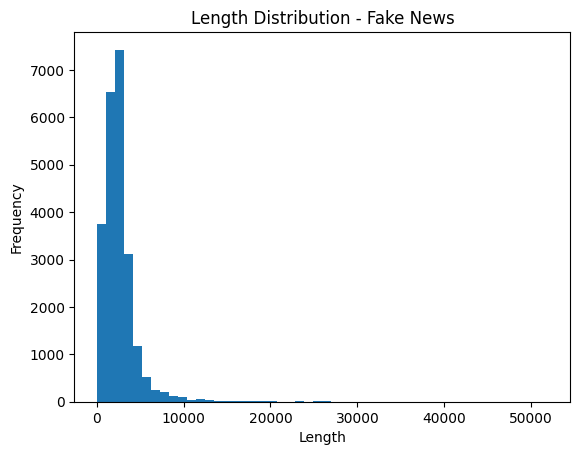

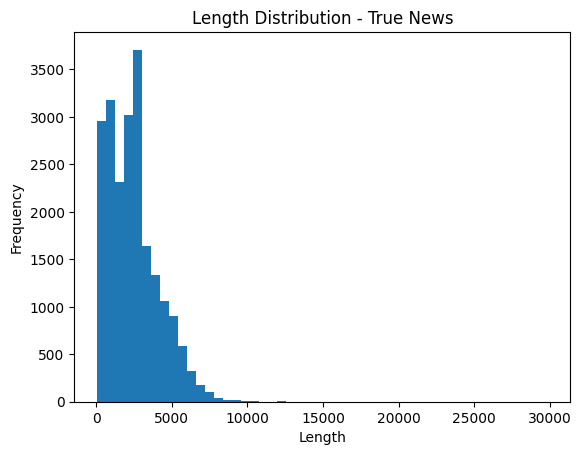

In [ ]:
#plot historgrams

fake_news = df[df['target'] == 0]
true_news = df[df['target'] == 1]
plt.hist(fake_news['length'], bins=50)

plt.title("Length Distribution - Fake News")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

plt.hist(true_news['length'], bins=50)

plt.title("Length Distribution - True News")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

### Write in words about the plots

It seems in these histograms, the distributions of both fake and true news is right skewed, this entails that most articles are short in length and dont have many outliers. We can see that the true news historgram is a little more spread out compared to the fake news one while the fake news historgram has more range with the tail extending further than true news. This long tail indicates some long articles however most of the articles are shorter. True news is generally more detailed and longer while fake news are shorter and less detailed according to these histrograms.

 ### What is TFIDF? How to create bag of words using sklearn? And how to generate TFIDF for the bag of words?

TFIDF, which stands for term frequency-inverse document frequency, is a statisitc used to evalutate the importance of certain words in a document in a collection of documents. It measures how frequently a word appears in a document and how important that word is across several other documents. You can generate TFIDF for a bag of words using TfidfTransformer in sklearn.

We can create a bag of words in sklearn using CountVectorizer. Bag of words is a model that converts text data into numbers by counting up all the times a word appears in a document and assigns it a index.

##Train Test Split

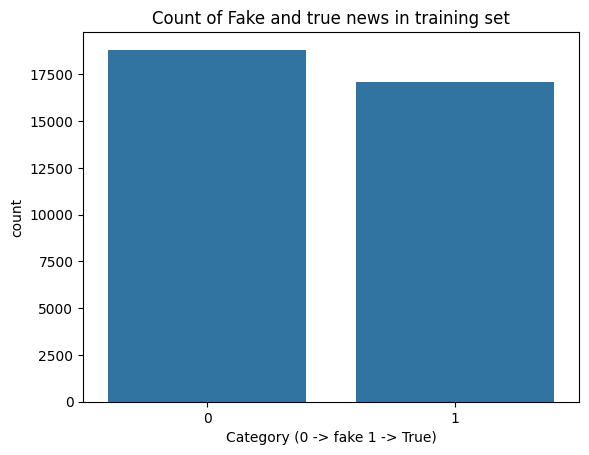

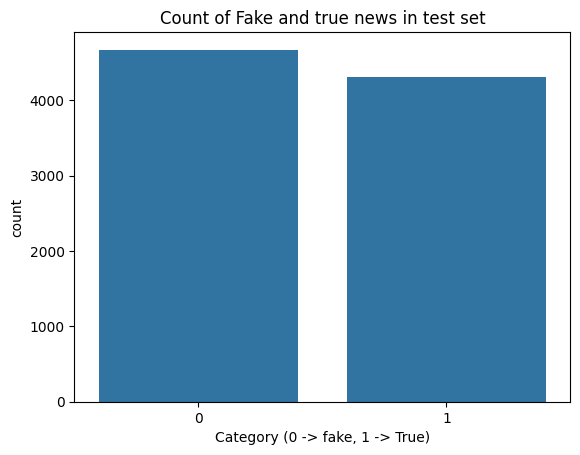

In [ ]:
X = df['AllText']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

sns.countplot(x=y_train)

plt.title("Count of Fake and true news in training set")
plt.xlabel("Category (0 -> fake 1 -> True)")
plt.ylabel("count")

plt.show()


sns.countplot(x=y_test)

plt.title("Count of Fake and true news in test set")
plt.xlabel("Category (0 -> fake, 1 -> True)")
plt.ylabel("count")

plt.show()


##Training and Testing Fake news classifier using MultinomialNB

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.neural_network import MLPClassifier
import string
from nltk.corpus import stopwords
from nltk.stem.lancaster import LancasterStemmer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
stemmer = LancasterStemmer()
stopwordList = stopwords.words('english')

def text_process(mess):

    mess = [char for char in mess if char not in string.punctuation]
    mess = ''.join(mess)

    words = nltk.word_tokenize(mess)
    words = [t for t in words if t.lower() not in stopwordList]
    words = [stemmer.stem(w.lower()) for w in words]

    return words

In [ ]:
#create a pipline
pipeline = Pipeline([('bow', CountVectorizer(analyzer=text_process, ngram_range=(1,2))),('tfidf', TfidfTransformer()),('classifier', MultinomialNB(alpha=0.1))])
#fit and perform prediction
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

#classification report
print(classification_report(y_test, predictions))
#confusion matrix
print(confusion_matrix(y_test, predictions))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


              precision    recall  f1-score   support

           0       0.97      0.96      0.96      4670
           1       0.95      0.97      0.96      4310

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980

[[4470  200]
 [ 132 4178]]


###Discuss the performance like how good the model is overall, how good is it in predicting fake news, and how good is it in predicting true news.

Based off the results of our model, we can conclude that our model performs well. We acheived an accuracy of 96% which means that our model is effective at distinguish between true and fake news. We got a precision of 0.97 and recall of 0.96. This means that our model is correct 97% of the time when predicting if a news article is fake and 96% correct when identifying all the actual fake news articles. Overall, the model is accurate and good at predicting fake news with not many misclassifications.

In [ ]:
#Copy a part of any news of your choice from a news website and then use the model to predict whether is it true or not.
new_news = """On a sweltering night in August 2024, moments before Robert F. Kennedy Jr. endorsed then-candidate Donald J. Trump at a packed rally in Arizona, a conservative young wellness podcaster named Alex Clark had a fleeting backstage conversation with the once-and-future president.

“I said, ‘Mr. President, please keep talking about food and pharma; this has a massive impact with undecided female voters,’ ” recalled Ms. Clark, now a leading conservative voice in Mr. Kennedy’s “Make America Healthy Again” movement. Witnessing the two men join forces, she said, “was the greatest political moment of my life.”

Not quite two years later, the MAHA movement is still a political force. But MAHA leaders warn that many of those who embrace the cause are dispirited and disillusioned — and that when the November elections come around, some may just stay home.

Six of the movement’s most prominent leaders, who together have millions of social media followers, said in separate interviews that the mostly white, mostly female voters who followed Mr. Kennedy into Mr. Trump’s camp are so disappointed with the president that Republicans risk losing them. But they said Democrats would need to work hard to win their votes."""

prediction = pipeline.predict([new_news])
print(prediction)

[0]


##Training and Testing a Deep Neural Network

In [ ]:
#create a pipline
pipeline_mlp = Pipeline([('bow', CountVectorizer(analyzer=text_process, max_features=15000)), ('tfidf', TfidfTransformer()), ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), verbose=2, max_iter=20, random_state=0,  early_stopping=True,))])
#fit and perform prediction
pipeline_mlp.fit(X_train, y_train)
predictions_mlp = pipeline_mlp.predict(X_test)

#classification report
print(classification_report(y_test, predictions_mlp))
#confusion matrix
print(confusion_matrix(y_test, predictions_mlp))

Iteration 1, loss = 0.18480530
Validation score: 0.996102
Iteration 2, loss = 0.00961202
Validation score: 0.997494
Iteration 3, loss = 0.00221793
Validation score: 0.997494
Iteration 4, loss = 0.00105678
Validation score: 0.997494
Iteration 5, loss = 0.00074450
Validation score: 0.997494
Iteration 6, loss = 0.00059902
Validation score: 0.997494
Iteration 7, loss = 0.00051770
Validation score: 0.997773
Iteration 8, loss = 0.00046564
Validation score: 0.997773
Iteration 9, loss = 0.00042912
Validation score: 0.997773
Iteration 10, loss = 0.00040182
Validation score: 0.997773
Iteration 11, loss = 0.00037994
Validation score: 0.997773
Iteration 12, loss = 0.00036167
Validation score: 0.997773
Iteration 13, loss = 0.00034574
Validation score: 0.997773
Iteration 14, loss = 0.00033172
Validation score: 0.997494
Iteration 15, loss = 0.00031866
Validation score: 0.997494
Iteration 16, loss = 0.00030661
Validation score: 0.997494
Iteration 17, loss = 0.00029522
Validation score: 0.997494
Iterat

###Discuss the performance like how good the model is overall, how good is it in predicting fake news, and how good is it in predicting true news.

This model acheived a overall accuracy of 99% which means it good at distinguishing between fake and true news. We have a precision of 1.00 meaning that any articles that was label fake was realyfake and the recall is 0.99 which indicated that we can sucessfuly capture 99% of all the fake articles. The MLP model is really goo at distinguishing fake news, it sucessfully learned any language patterns that help it distinguish misinformation or overexaggerated news. This model also shows signs of possibily overfitting as its high accuracy meanis that the model might be memorizing training patters. We used early_stopping whihc does help reduce overfitting but it's not guanranteed to help.

In [ ]:
#Use the same news you have used above and then use the model to predict whether is it true or not.
new_news = """On a sweltering night in August 2024, moments before Robert F. Kennedy Jr. endorsed then-candidate Donald J. Trump at a packed rally in Arizona, a conservative young wellness podcaster named Alex Clark had a fleeting backstage conversation with the once-and-future president.

“I said, ‘Mr. President, please keep talking about food and pharma; this has a massive impact with undecided female voters,’ ” recalled Ms. Clark, now a leading conservative voice in Mr. Kennedy’s “Make America Healthy Again” movement. Witnessing the two men join forces, she said, “was the greatest political moment of my life.”

Not quite two years later, the MAHA movement is still a political force. But MAHA leaders warn that many of those who embrace the cause are dispirited and disillusioned — and that when the November elections come around, some may just stay home.

Six of the movement’s most prominent leaders, who together have millions of social media followers, said in separate interviews that the mostly white, mostly female voters who followed Mr. Kennedy into Mr. Trump’s camp are so disappointed with the president that Republicans risk losing them. But they said Democrats would need to work hard to win their votes."""

prediction_mlp = pipeline_mlp.predict([new_news])
print(prediction_mlp)

[0]


###Discuss any difference in performance between this model and NB model

Both the multilayer perceptron model and multinomial naives bayes model both performed generally well on fake news  however there were few slight differences. For example the main difference btween the two models is runtime, the Naive Bayes model was much simplaer and ran much quicer tha the MLP model and the MLP model is more computationally expensive and complex. The MLP model acheives 99% accuracy and the NB model achieved 96%, this just means the MLP model is better at capturing the mor complext patterns in outr data. Though there are many difference there are some similarities such as both models generally mistakenly classify true news as fake, this just indicates that it faces challenges on generalizing to unseen data (as concluded in the prediction where we got a snippet of news from an article alone and got a result of 0-> whihc means fake news). Overall MLP model was better at classifying fake news compares to NB model and achieved a higher accuracy.

##Extra Credit

In [ ]:
# preprocess data
df_subject = df_copy[['subject', 'title', 'text']].copy()

df_subject['AllText'] = df_subject['title'] + " " + df_subject['text']

#train and test split
from sklearn.model_selection import train_test_split

X = df_subject['AllText']
y = df_subject['subject']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0,stratify=y)

#neural network pipeline
pipeline_subject = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process, max_features=20000)),
    ('tfidf', TfidfTransformer()),
    ('classifier', MLPClassifier(hidden_layer_sizes=(20, 10),verbose=2, max_iter=15, random_state=0))])

In [ ]:
pipeline_subject.fit(X_train, y_train)

predictions_subject = pipeline_subject.predict(X_test)

print(classification_report(y_test, predictions_subject))
print(confusion_matrix(y_test, predictions_subject))

Iteration 1, loss = 1.46076941
Iteration 2, loss = 0.80661336
Iteration 3, loss = 0.57527561
Iteration 4, loss = 0.45099069
Iteration 5, loss = 0.37196132
Iteration 6, loss = 0.32832263
Iteration 7, loss = 0.30299458
Iteration 8, loss = 0.28522854
Iteration 9, loss = 0.27129074
Iteration 10, loss = 0.25984889
Iteration 11, loss = 0.25005287
Iteration 12, loss = 0.24119796
Iteration 13, loss = 0.23398802
Iteration 14, loss = 0.22710686
Iteration 15, loss = 0.22128626


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


                 precision    recall  f1-score   support

Government News       0.13      0.09      0.10       314
    Middle-east       0.19      0.21      0.20       156
           News       0.97      0.96      0.96      1810
        US_News       0.10      0.08      0.09       157
      left-news       0.15      0.16      0.15       892
       politics       0.37      0.39      0.38      1368
   politicsNews       0.98      0.96      0.97      2254
      worldnews       0.96      0.97      0.96      2029

       accuracy                           0.74      8980
      macro avg       0.48      0.48      0.48      8980
   weighted avg       0.74      0.74      0.74      8980

[[  28    0    3    0   82  197    3    1]
 [   1   33    1  120    1    0    0    0]
 [   6    0 1731    0   22   51    0    0]
 [   2  140    1   13    1    0    0    0]
 [  50    1   15    0  139  682    1    4]
 [ 125    0   37    1  655  537    5    8]
 [   2    0    2    0    4    4 2171   71]
 [   7    0 

###Short discription on this model

For the deep Neural Network model we achieved a accuracy of 80%. This model has some strong points on some certain variables and weakness on other variables. An example is for politicsNews we got a F1score of 0.97 while Government news got a F1-score of 0. We see these varying f1scores due to the terminology of each article its identifying.We also see this trend on recall. These drastic metrics most likely comes from data imbalance as there is not enough data to distinguish between variables.

While the model is highly  effective at identifying more braod topics that have more data, the model fails at more specific terms or terms that are bery similar to other terms. This model will need more data to be more balanced to help with distinguishing betwen subjects.